In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

![Sepals](https://www.sciencefacts.net/wp-content/uploads/2021/12/Sepals.jpg)

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

# show data 50 rows
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
print(iris_df.head(5))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [15]:
# summary statistics
print(iris_df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [16]:
# Split the dataset into features and target variable
X = iris.data
y = iris.target

In [7]:
# Encode the target labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# แสดงข้อมูล
print("Features (X):")
print(X[:5])  # แสดง 5 แถวแรกของข้อมูล
print("\nEncoded Labels (y):")
print(y_encoded[:5])  # แสดง 5 แถวแรกของป้ายกำกับ
print("\nCategorical Labels (y_categorical):")      
print(y_categorical[:5])  # แสดง 5 แถวแรกของป้ายกำกับแบบ categorical

Features (X):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Encoded Labels (y):
[0 0 0 0 0]

Categorical Labels (y_categorical):
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [17]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:

# Build the ANN model
model = Sequential([
    Dense(8, input_dim=X_train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)



Epoch 1/50


/opt/homebrew/Caskroom/miniconda/base/envs/lab743/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4750 - loss: 0.9650  
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5083 - loss: 0.9119
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5750 - loss: 0.8667
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5833 - loss: 0.8263
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6250 - loss: 0.7904
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6833 - loss: 0.7593
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6917 - loss: 0.7312
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.7000 - loss: 0.7062
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7167 - loss: 0.6857
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.7250 - loss: 0.6663
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.7333 - loss: 0.6499
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.7167 - los

Test Accuracy: 1.00


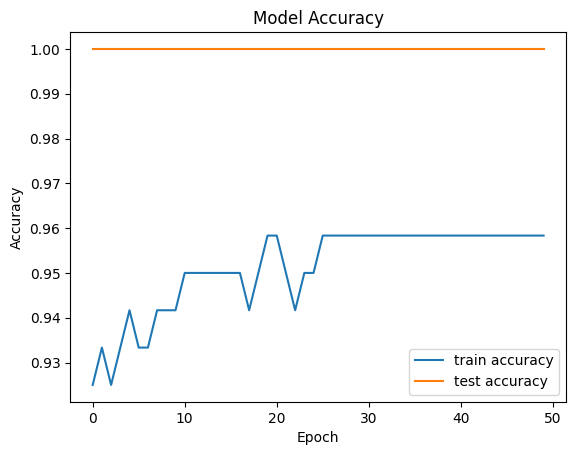

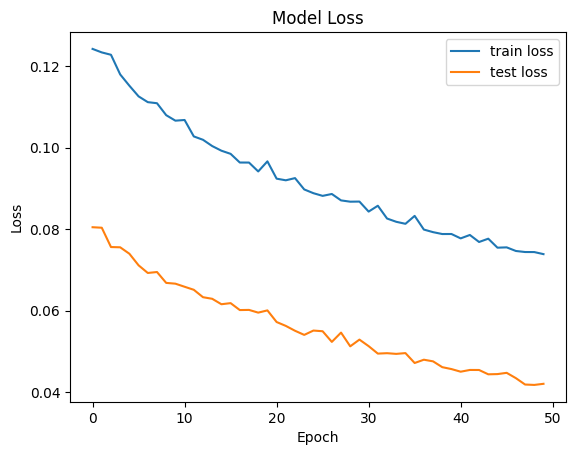

In [20]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

# show loss and accuracy as a plot
import matplotlib.pyplot as plt
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0, validation_data=(X_test, y_test)) 
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.title('Model Loss')     
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [22]:
# show X_test and y_test
print("X_test:")
print(X_test[:5])  # แสดง 5 แถวแรกของข้อมูลทดสอบ
print("\ny_test:")
print(y_test[:5])  # แสดง 5 แถวแรกของป้ายกำกับทดสอบ    


X_test:
[[ 0.35451684 -0.58505976  0.55777524  0.02224751]
 [-0.13307079  1.65083742 -1.16139502 -1.17911778]
 [ 2.30486738 -1.0322392   1.8185001   1.49058286]
 [ 0.23261993 -0.36147005  0.44316389  0.4227026 ]
 [ 1.2077952  -0.58505976  0.61508092  0.28921757]]

y_test:
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [23]:
# Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Display results
print("Predicted classes:", predicted_classes)
print("True classes:", true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted classes: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True classes: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
